In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import pycountry
import os 
import ast
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

In [4]:
netflix_df = pd.read_csv(r"C:\Users\Vaibhav\Downloads\project\netflix_movies_detailed_up_to_2025.csv")
netflix_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.000,NaN,Music,es,NaN,4.931,0,0.000,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,NaN,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.000,NaN,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.000,NaN,NaN,en,A Dunces Burden,4.921,0,0.000,0,0


In [6]:
# assign catagorical and numerical column 
cat_col = netflix_df.select_dtypes(include='object').columns
num_col = netflix_df.select_dtypes(exclude='object').columns 
cat_col, num_col

(Index(['type', 'title', 'director', 'cast', 'country', 'date_added', 'genres',
        'language', 'description'],
       dtype='object'),
 Index(['show_id', 'release_year', 'rating', 'duration', 'popularity',
        'vote_count', 'vote_average', 'budget', 'revenue'],
       dtype='object'))

In [8]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [10]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [12]:
netflix_df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.0,NaN,Music,es,NaN,4.931,0,0.0,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.0,NaN,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.0,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.0,NaN,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.0,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.0,NaN,NaN,en,A Dunces Burden,4.921,0,0.0,0,0
15999,1405742,Movie,Portal to Hell,Woody Bess,"Trey Holland, Keith David, Richard Kind, Micha...",United States of America,2025-02-22,2025,0.0,NaN,"Comedy, Horror",en,After a debt-collector finds a portal to hell ...,4.921,0,0.0,0,0


In [14]:
netflix_df.shape

(16000, 18)

In [16]:
netflix_df.columns 

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average', 'budget',
       'revenue'],
      dtype='object')

In [18]:
netflix_df.isnull().sum()

show_id             0
type                0
title               0
director          132
cast              204
country           466
date_added          0
release_year        0
rating              0
duration        16000
genres            107
language            0
description       132
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

# Missing Values analysis 

- in the netflix df the director, cast, country, duration, genres, description has null values 

- the duration column cantains the 100% null values then we drop the duration column 

- and other column we fill it 

In [22]:
netflix_df = netflix_df.drop(columns = ['duration'])
netflix_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1440286,Movie,Festival de Viña del Mar 2025: Ha*Ash,NaN,Ha*ash,Chile,2025-02-24,2025,0.000,Music,es,NaN,4.931,0,0.000,0,0
15996,1271724,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,Drama,ru,Poignant stories about men and women who have ...,4.930,0,0.000,0,0
15997,1426364,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",NaN,2025-01-28,2025,1.000,Horror,en,Two villainous entities initiate gorgeous soro...,4.922,1,1.000,0,0
15998,1411248,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",NaN,2025-03-10,2025,0.000,NaN,en,A Dunces Burden,4.921,0,0.000,0,0


- **the remainig columns are the catagorical column then we fill missing values with mode**

In [25]:
col = ['director', 'cast', 'country', 'genres', 'description']

for i in col:
    mode = netflix_df[i].mode()[0]
    netflix_df[i] = netflix_df[i].fillna(mode)

netflix_df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
genres          0
language        0
description     0
popularity      0
vote_count      0
vote_average    0
budget          0
revenue         0
dtype: int64

# data preprocess

- the date time column consist the date but in object formate then we convert into the datetiem formate 

In [27]:
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'])
netflix_df['date_added'].dtypes  # the date_added column converted into the date time formate 

dtype('<M8[ns]')

- the country column names are to long then we convert into short using pycountry module 

In [29]:

def get_country_code(name):
    try:
        return pycountry.countries.lookup(name.strip()).alpha_3
    except:
        return name  # keepis same 

def convert_countries(cell):
    if pd.isna(cell):
        return cell
    parts = [p.strip() for p in str(cell).split(',')]
    codes = []
    for p in parts:
        code = get_country_code(p)
        codes.append(code)
    return ', '.join(codes)

# we allply conversion to the counry column
netflix_df['country'] = netflix_df['country'].apply(convert_countries)

# then we check the result
print(netflix_df[['country']].head(10))


         country
0            USA
1       GBR, USA
2       GBR, USA
3            USA
4            USA
5            USA
6  CHN, HKG, USA
7            USA
8            USA
9       FRA, ESP


- the genres column contains more string in a single block then we will split multi genres string into a list

- the genres column also contains the other nan or none then we assign as unknown 

In [31]:
netflix_df['genres'].head()

0    Comedy, Adventure, Fantasy, Animation, Family
1               Action, Science Fiction, Adventure
2                               Adventure, Fantasy
3                     Animation, Family, Adventure
4            Fantasy, Adventure, Animation, Family
Name: genres, dtype: object

In [33]:
non_str_mask = ~netflix_df['genres'].apply(lambda x: isinstance(x, str))

if non_str_mask.sum() > 0:
    display(netflix_df.loc[non_str_mask, ['title', 'genres']].head(10))

# --- robust cleaner function ---
def split_genres_cell(x):
    # handle pandas NA / numpy nan
    if pd.isna(x):
        return ['Unknown']
    # if it's already a list (maybe cleaned earlier), return as-is
    if isinstance(x, list):
        return x
    # otherwise convert to string (handles numbers/floats) and split by comma
    s = str(x).strip()
    if s == '' or s.lower() in {'nan', 'none'}:
        return ['Unknown']
    # split and strip whitespace
    return [g.strip() for g in s.split(',') if g.strip() != '']

# Apply the function
netflix_df['genres'] = netflix_df['genres'].apply(split_genres_cell)
netflix_df['genres']

0        [Comedy, Adventure, Fantasy, Animation, Family]
1                   [Action, Science Fiction, Adventure]
2                                   [Adventure, Fantasy]
3                         [Animation, Family, Adventure]
4                [Fantasy, Adventure, Animation, Family]
                              ...                       
15995                                            [Music]
15996                                            [Drama]
15997                                           [Horror]
15998                                            [Drama]
15999                                   [Comedy, Horror]
Name: genres, Length: 16000, dtype: object

- the show_id column contains the all values are unique then  we drop the column to better understanding

- and the description column is full with txt then we also drop the discription column 

In [36]:
netflix_df = netflix_df.drop(columns='show_id')
netflix_df = netflix_df.drop(columns='description')
netflix_df


,type,title,director,cast,country,date_added,release_year,rating,genres,language,popularity,vote_count,vote_average,budget,revenue
0,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",USA,2010-05-16,2010,6.380,"[Comedy, Adventure, Fantasy, Animation, Family]",en,203.893,7449,6.380,165000000,752600867
1,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","GBR, USA",2010-07-15,2010,8.369,"[Action, Science Fiction, Adventure]",en,156.242,37119,8.369,160000000,839030630
2,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","GBR, USA",2010-11-17,2010,7.744,"[Adventure, Fantasy]",en,121.191,19327,7.744,250000000,954305868
3,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",USA,2010-11-24,2010,7.600,"[Animation, Family, Adventure]",en,111.762,11638,7.600,260000000,592461732
4,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",USA,2010-03-18,2010,7.800,"[Fantasy, Adventure, Animation, Family]",en,110.044,13259,7.800,165000000,494879471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,Movie,Festival de Viña del Mar 2025: Ha*Ash,Tyler Perry,Ha*ash,CHL,2025-02-24,2025,0.000,[Music],es,4.931,0,0.000,0,0
15996,Movie,Man and Woman,Vladimir Kott,"Anna Kotova, Stepan Devonin, Pavel Derevyanko,...",Russia,2025-03-13,2025,0.000,[Drama],ru,4.930,0,0.000,0,0
15997,Movie,Night of the Dead Sorority Babes,"Angel Nichole Bradford, Steve Hermann","Jessa Flux, Lynn Lowry, Angel Nichole Bradford...",USA,2025-01-28,2025,1.000,[Horror],en,4.922,1,1.000,0,0
15998,Movie,A Dunces Burden,Daniel Kowal,"Riley G, Mitchel Corrado",USA,2025-03-10,2025,0.000,[Drama],en,4.921,0,0.000,0,0


# catagorical & Numerical column analysis 

- univariate analysis

- Bivariate analysis

- Multivariate analysis 

- the type column contains the unique movie 

In [42]:
netflix_df[['type']].value_counts()

type 
Movie    16000
Name: count, dtype: int64

- the top 5 country are watch movies on netflix 

In [44]:
netflix_df['country'].value_counts().head(5)

country
USA    5887
JPN     845
KOR     789
FRA     612
GBR     581
Name: count, dtype: int64

- there is the top 5 genres are people watch most on netflix 

In [50]:
netflix_df['genres'].value_counts().head(5)

genres
[Drama]             1443
[Comedy]             776
[Documentary]        587
[Drama, Romance]     473
[Horror]             391
Name: count, dtype: int64

- the directors has directed most movies 

In [206]:
netflix_df['director'].value_counts().head()

director
Tyler Perry          152
Sean McNamara         15
Steven Soderbergh     15
Roel Reiné            15
Choi Woo-seong        14
Name: count, dtype: int64

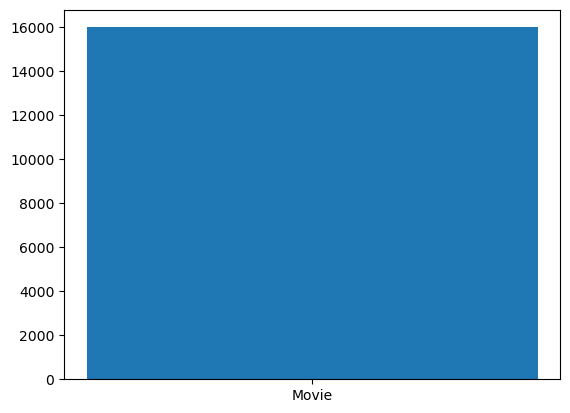

In [52]:
k = netflix_df['type'].value_counts().keys()
v = netflix_df['type'].value_counts().values
plt.bar(k, v)
plt.savefig('images/movie_type.png')

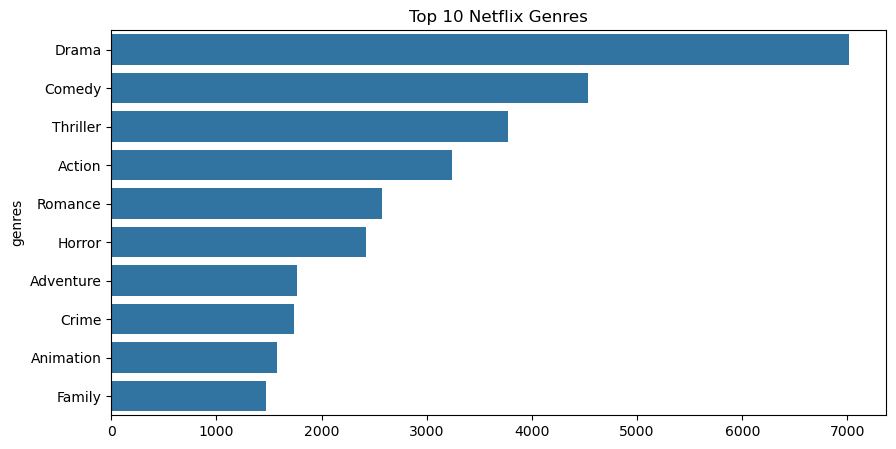

In [54]:
plt.figure(figsize=(10,5))
top_genres = netflix_df['genres'].explode().value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Netflix Genres")
plt.savefig('images/Genres.png')
plt.show()

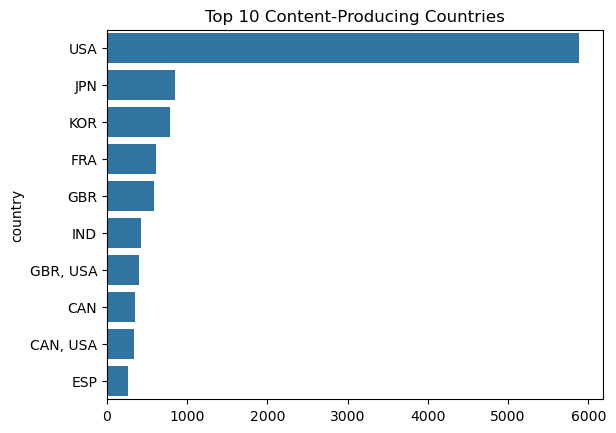

In [56]:
top_countries = netflix_df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content-Producing Countries")
plt.savefig('images/country.png')


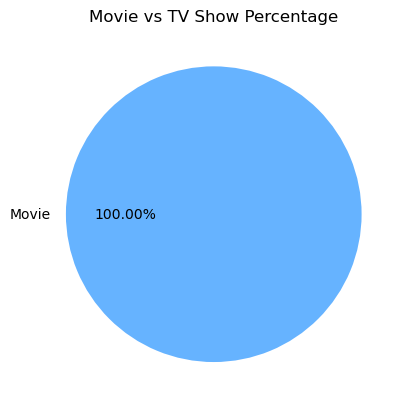

In [58]:
key = netflix_df['type'].value_counts().keys()
values = netflix_df['type'].value_counts().values
plt.pie(x=values, labels=key, autopct='%0.2f%%', colors=['#66b3ff','#99ff99']) 
plt.title("Movie vs TV Show Percentage")
plt.ylabel('')
plt.savefig('images/pie_type.png')
plt.show()

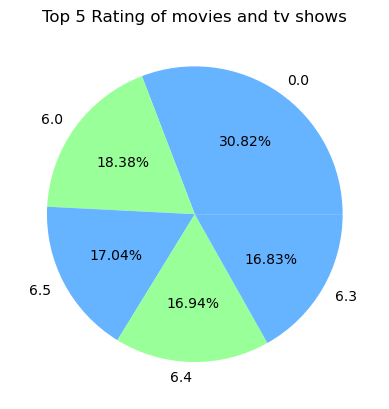

In [60]:
key = netflix_df['rating'].value_counts().head(5).keys()
values = netflix_df['rating'].value_counts().head(5).values
plt.pie(x=values, labels=key, autopct='%0.2f%%', colors=['#66b3ff','#99ff99']) 
plt.title("Top 5 Rating of movies and tv shows")
plt.ylabel('')
plt.savefig('images/pie_rating.png')
plt.show()

In [252]:
netflix_df.describe()


,date_added,release_year,rating,popularity,vote_count,vote_average,budget,revenue
count,16000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,2018-01-04 21:54:37.799999744,2017.500000,5.956368,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
min,2010-01-01 00:00:00,2010.000000,0.000000,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2013-12-31 18:00:00,2013.750000,5.600000,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,2017-12-31 12:00:00,2017.500000,6.300000,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,2021-12-31 06:00:00,2021.250000,6.923000,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,2025-12-25 00:00:00,2025.000000,10.000000,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09
std,NaN,4.609916,1.754741,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08


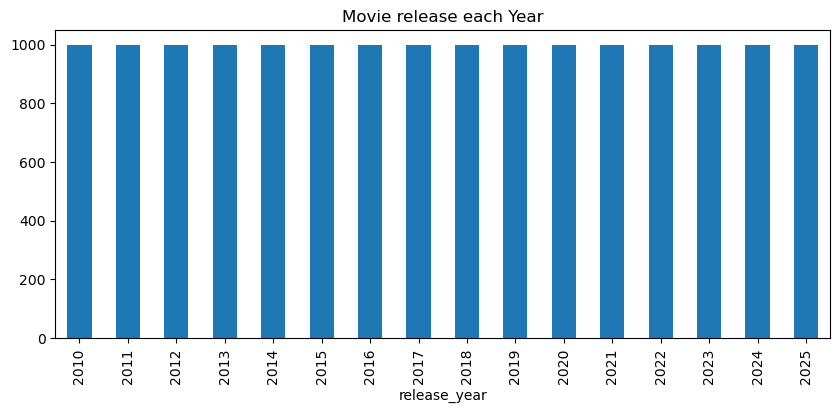

In [62]:
netflix_df['release_year'].value_counts().sort_index().plot(kind='bar', figsize=(10,4), title='Movie release each Year')
plt.savefig('images/release_year.png')

- the above histogram tells the movie release in each year is same 

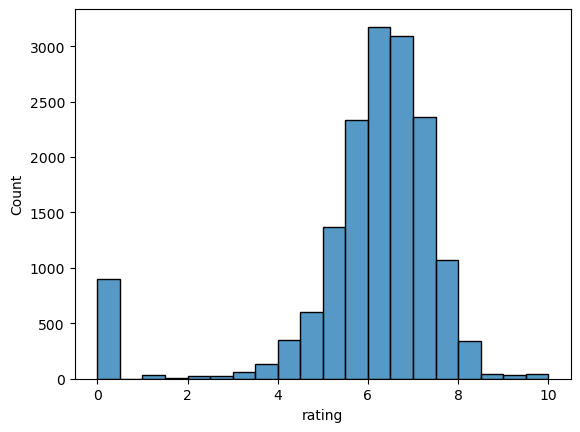

In [64]:
sns.histplot(netflix_df['rating'], bins=20)
plt.savefig('images/rating.png')

- conslusion :- Netflix’s data maintains average-to-good viewer ratings, with consistent quality levels.

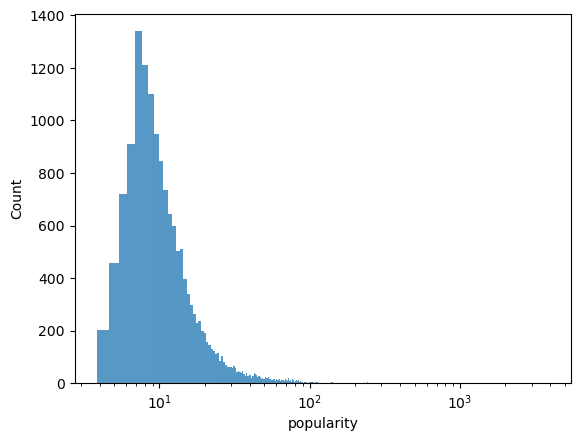

In [66]:
data = netflix_df['popularity']
sns.histplot(x=data)
plt.xscale('log')
plt.savefig('images/hist_popularity')

- conclusion: Netflix’s watch trends are power-law distributed — a small fraction of content drives major engagement.

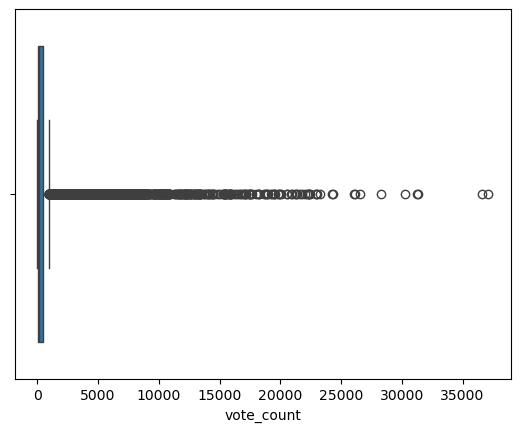

In [68]:
data =netflix_df['vote_count']
sns.boxplot(data, orient='h')
plt.savefig('images/box_votecount.png')

- Conclusion:- Netflix viewership and interaction are highly uneven — driven by viral or trending titles.

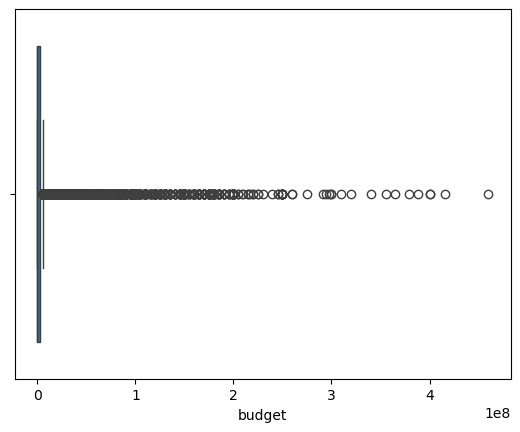

In [70]:
data = netflix_df['budget']
sns.boxplot(data, orient='h')
plt.savefig('images/box_budget')

- Conclusion: The Budget Values are Higly Skewed and most netflix production are low to mid budget, with some big hit 

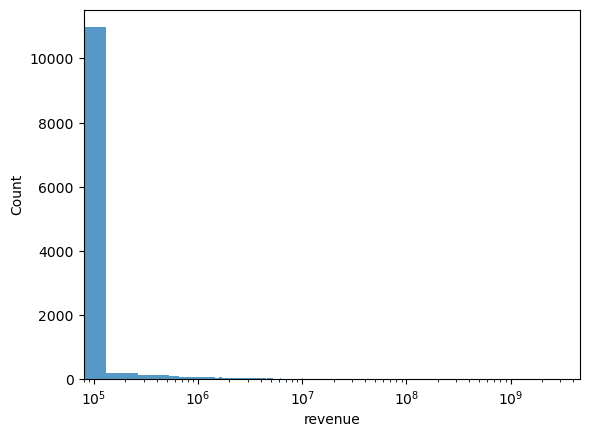

In [72]:
data = netflix_df['revenue']
sns.histplot(data)
plt.xscale('log')
plt.savefig('images/box_revenue')

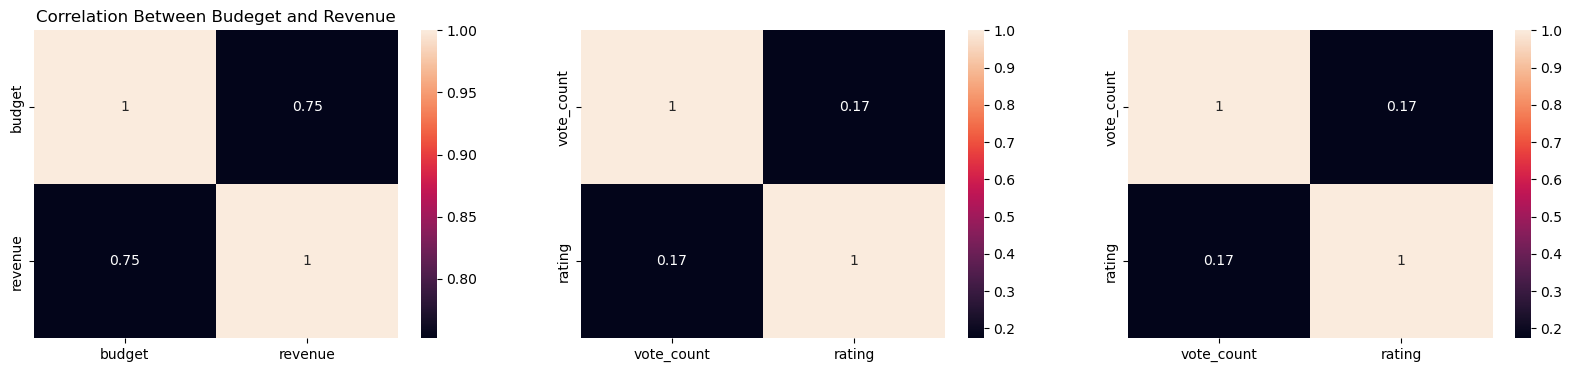

In [80]:
plt.figure(figsize=(20,4))

corr1 = netflix_df[['budget', 'revenue']].corr()
plt.subplot(1,3,1)
sns.heatmap(corr1, annot=True)
plt.title('Correlation Between Budeget and Revenue')


corr2 = netflix_df[['vote_count', 'rating']].corr()
plt.subplot(1,3,2)
sns.heatmap(corr2, annot=True)


corr3 = netflix_df[['popularity', 'vote_count']].corr()
plt.subplot(1,3,3)
sns.heatmap(corr2, annot=True)

plt.savefig('images/heatmap.png')

# conclusion
- budget and  revenue: Higher-budget movies generally tend to earn more revenue, indicating that 
                        investment in production and marketing directly impacts financial success.

- rating and vote_average: Titles with higher audience engagement (more votes) often have better ratings, 
                            but the correlation isn’t perfect — popularity doesn’t always guarantee high quality..

- popularity and vote_count: Highly popular titles naturally receive more audience votes, showing that popularity
                             metrics effectively reflect audience activity and engagement.

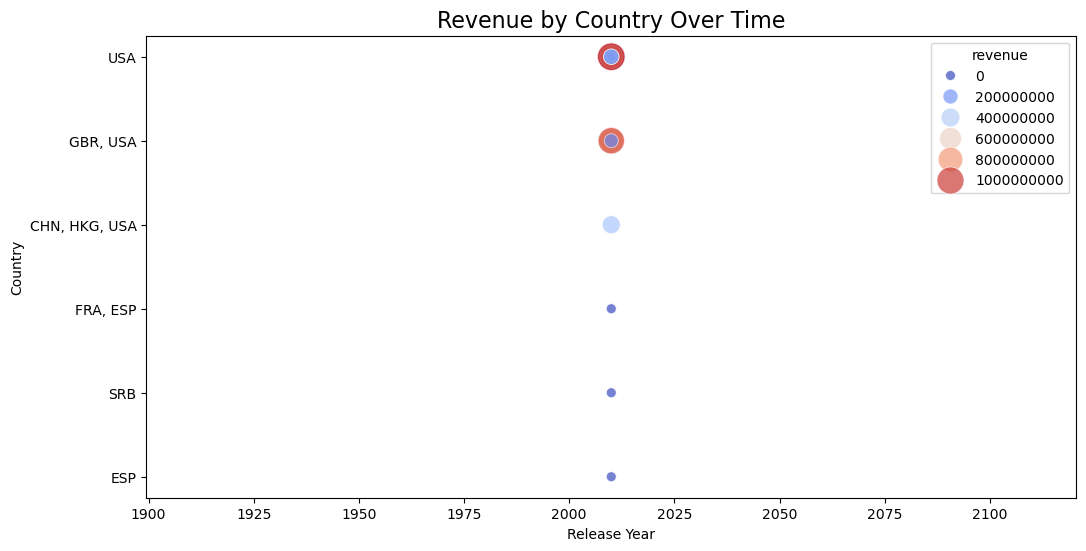

In [130]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=netflix_df.head(20),
    x='release_year',
    y='country',
    size='revenue',
    hue='revenue',
    sizes=(50, 400),
    palette='coolwarm',
    alpha=0.7
)
plt.title('Revenue by Country Over Time', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('Country')
plt.savefig('images/scatter.png')
plt.show()


In [108]:
netflix_df['country'].tail(10)

15990                                                  GBR
15991    DEU, SAU, QAT, FRA, GRC, NLD, GBR, Palestinian...
15992                                                  CAN
15993                                                  CAN
15994                                                  USA
15995                                                  CHL
15996                                               Russia
15997                                                  USA
15998                                                  USA
15999                                                  USA
Name: country, dtype: object

- Conclusion: Revenue generation in Netflix movies is dominated by U.S. productions, and international markets contribute less comparatively. The years 2018–2021 mark peak revenue periods, indicating possibly more blockbuster releases or Netflix expansion during that time.

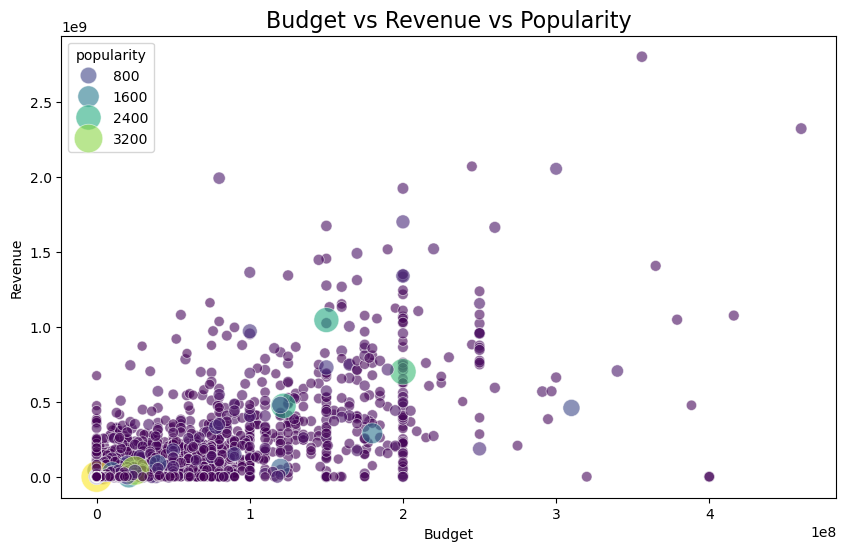

In [132]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=netflix_df,
    x='budget',
    y='revenue',
    size='popularity',
    hue='popularity',
    sizes=(50, 500),
    alpha=0.6,
    palette='viridis'
)
plt.title('Budget vs Revenue vs Popularity', fontsize=16)
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.savefig('images/scatter_2.png')
plt.show()


- conslusion : There is a strong positive relationship between budget, popularity, and revenue.

# Outlier Analysis

- Columns such as rating, vote_average, and release_year have bounded or discrete values, so we do not treat them as outliers.

- We do the outlier analysis on the budget, revenue, popularity, vote_count columns 

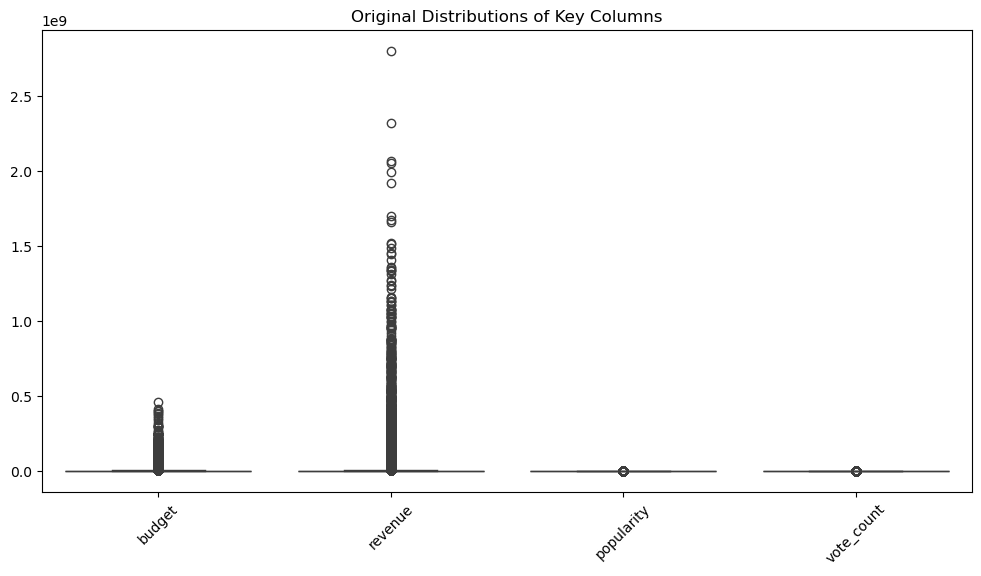

In [136]:

cols = ['budget', 'revenue', 'popularity', 'vote_count']
plt.figure(figsize=(12, 6))
sns.boxplot(data=netflix_df[cols])
plt.title('Original Distributions of Key Columns')
plt.xticks(rotation=45)
plt.savefig('images/box_outlier.png')
plt.show()


In [140]:
# Remove rows where 'budget' or 'revenue' are negative
netflix_df= netflix_df[(netflix_df['budget'] >= 0) & (netflix_df['revenue'] >= 0)]

# Define a function to cap values at the 1st and 99th percentiles
def cap_outliers(netflix_df, cols):
    for col in cols:
        lower = netflix_df[col].quantile(0.01)
        upper = netflix_df[col].quantile(0.99)
        netflix_df[col] = netflix_df[col].clip(lower, upper)
    return netflix_df

# Apply the function
netflix_df = cap_outliers(netflix_df, cols)


In [142]:
# Apply log transformation to reduce skewness
for col in cols:
    netflix_df[f'log_{col}'] = np.log1p(netflix_df[col])  # log1p handles zero values safely

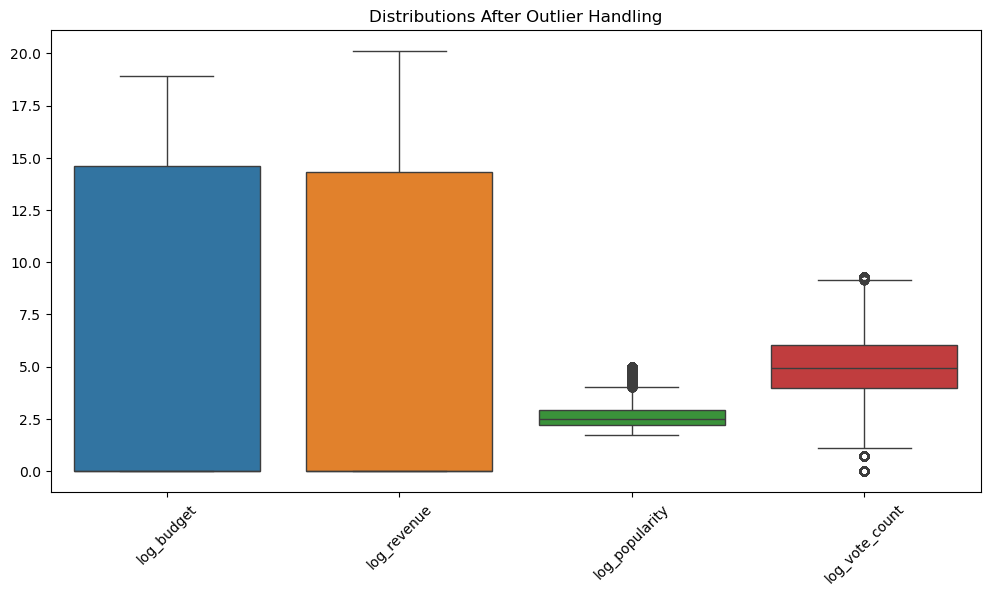

In [144]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=netflix_df[[f'log_{col}' for col in cols]])
plt.title('Distributions After Outlier Handling')
plt.xticks(rotation=45)
plt.savefig('images/box_without_outlier.png')
plt.show()

- Conclusion :

- After removing invalid values, capping extremes, and applying log transformation, the skewness in budget, revenue, popularity, and vote_count was reduced. The boxplots now show fewer extreme points, indicating a more balanced and cleaner data distribution for analysis.

# Encoding

In [146]:
# we will drop the text- heavy or identifier columns 

netflix_df.drop(['title', 'director', 'cast', 'description'], axis=1, inplace=True, errors='ignore')

In [148]:
# we use label encoder for simple and binary column 
le = LabelEncoder()
netflix_df['type'] = le.fit_transform(netflix_df['type']) 
netflix_df['type']

0        0
1        0
2        0
3        0
4        0
        ..
15995    0
15996    0
15997    0
15998    0
15999    0
Name: type, Length: 16000, dtype: int32

In [150]:
# we will do onehot encoder for nominal columns 
def clean_list_column(col):
    # Convert string representations of lists to real lists
    return col.apply(lambda x: ', '.join(ast.literal_eval(x)) if isinstance(x, str) and x.startswith('[') else str(x))

for c in ['country', 'genres', 'language']:
    netflix_df[c] = clean_list_column(netflix_df[c])

# Create one-hot encoded columns for each multi-value category
genres_dummies = netflix_df['genres'].str.get_dummies(sep=', ')
country_dummies = netflix_df['country'].str.get_dummies(sep=', ')
language_dummies = netflix_df['language'].str.get_dummies(sep=', ')

# Merge back into main dataframe
netflix_df = pd.concat([netflix_df, genres_dummies, country_dummies, language_dummies], axis=1)

# Drop the original text columns
netflix_df = netflix_df.drop(['genres', 'country', 'language'], axis=1)
netflix_df

,type,date_added,release_year,rating,popularity,vote_count,vote_average,budget,revenue,log_budget,...,th,tl,tr,uk,ur,vi,xx,yo,zh,zu
0,0,2010-05-16,2010,6.380,144.48478,7449.00,6.380,1.650000e+08,5.432866e+08,18.921456,...,0,0,0,0,0,0,0,0,0,0
1,0,2010-07-15,2010,8.369,144.48478,10616.24,8.369,1.600000e+08,5.432866e+08,18.890684,...,0,0,0,0,0,0,0,0,0,0
2,0,2010-11-17,2010,7.744,121.19100,10616.24,7.744,1.650500e+08,5.432866e+08,18.921759,...,0,0,0,0,0,0,0,0,0,0
3,0,2010-11-24,2010,7.600,111.76200,10616.24,7.600,1.650500e+08,5.432866e+08,18.921759,...,0,0,0,0,0,0,0,0,0,0
4,0,2010-03-18,2010,7.800,110.04400,10616.24,7.800,1.650000e+08,4.948795e+08,18.921456,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,0,2025-02-24,2025,0.000,4.93100,0.00,0.000,0.000000e+00,0.000000e+00,0.000000,...,0,0,0,0,0,0,0,0,0,0
15996,0,2025-03-13,2025,0.000,4.93000,0.00,0.000,0.000000e+00,0.000000e+00,0.000000,...,0,0,0,0,0,0,0,0,0,0
15997,0,2025-01-28,2025,1.000,4.92200,1.00,1.000,0.000000e+00,0.000000e+00,0.000000,...,0,0,0,0,0,0,0,0,0,0
15998,0,2025-03-10,2025,0.000,4.92100,0.00,0.000,0.000000e+00,0.000000e+00,0.000000,...,0,0,0,0,0,0,0,0,0,0


In [152]:
# Convert to datetime
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], errors='coerce')

# we will convert from day since 
ref_date = pd.to_datetime('2000-01-01')
netflix_df['days_since_added'] = (netflix_df['date_added'] - ref_date).dt.days

# we will drop the numerical values 
netflix_df.drop('date_added', axis=1, inplace=True)

- Conclussion:- The date_added column was converted to a numeric feature days_since_added representing the number of days since January 1, 2000. The original date_added column was dropped, making the dataset ready for numerical analysis and scaling.

In [163]:
numerical_cols = ['days_since_added', 'release_year', 'rating', 
                  'popularity', 'vote_count', 'vote_average', 
                  'budget', 'revenue']

netflix_df[numerical_cols] = netflix_df[numerical_cols].apply(pd.to_numeric, errors='coerce')

scaler_std = StandardScaler()
netflix_df[numerical_cols] = scaler_std.fit_transform(netflix_df[numerical_cols])
netflix_df.to_csv('images/Netflix_EDA.csv')
netflix_df

,type,release_year,rating,popularity,vote_count,vote_average,budget,revenue,log_budget,log_revenue,...,tl,tr,uk,ur,vi,xx,yo,zh,zu,days_since_added
0,0,-1.626978,0.241429,6.031468,4.201548,0.241429,6.208974,6.876873,18.921456,20.113147,...,0,0,0,0,0,0,0,0,0,-1.666426
1,0,-1.626978,1.374965,6.031468,6.162081,1.374965,6.010900,6.876873,18.890684,20.113147,...,0,0,0,0,0,0,0,0,0,-1.630600
2,0,-1.626978,1.018776,4.923939,6.162081,1.018776,6.210954,6.876873,18.921759,20.113147,...,0,0,0,0,0,0,0,0,0,-1.555964
3,0,-1.626978,0.936710,4.475627,6.162081,0.936710,6.210954,6.876873,18.921759,20.113147,...,0,0,0,0,0,0,0,0,0,-1.551785
4,0,-1.626978,1.050690,4.393942,6.162081,1.050690,6.208974,6.239880,18.921456,20.019825,...,0,0,0,0,0,0,0,0,0,-1.701654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,0,1.626978,-3.394549,-0.603774,-0.409412,-3.394549,-0.327439,-0.272281,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,1.556665
15996,0,1.626978,-3.394549,-0.603821,-0.409412,-3.394549,-0.327439,-0.272281,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,1.566816
15997,0,1.626978,-2.824646,-0.604201,-0.408793,-2.824646,-0.327439,-0.272281,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,1.540544
15998,0,1.626978,-3.394549,-0.604249,-0.409412,-3.394549,-0.327439,-0.272281,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,1.565024


- All numerical columns, we transform all the columns into numerical column 

- **Summary**

- Netflix continues to expand content volume post-2015, with a strong focus on Movies, English-language content, and Drama/Comedy genres.

- The platform has diversified globally but remains largely dominated by U.S. productions.

- Its catalog is targeted at a teen and adult audience, with increasing experimentation in regional and international content.